In [1]:
import pandas as pd
import numpy as np

In [2]:
data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv"

In [3]:
#!wget $data

# Data Preparation

In [4]:
df = pd.read_csv(data)

In [5]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [7]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [8]:
df.dtypes #We are interested in str data types.

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
strings = list(df.dtypes[df.dtypes == 'str'].index)

In [10]:
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [11]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [12]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# Exploratory Data Analysis

In [13]:
# Lets look at our data

In [14]:
for cols in df.columns:
    print(cols)
    print(df[cols].unique()[:5])
    print(df[cols].nunique())
    print()
    

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

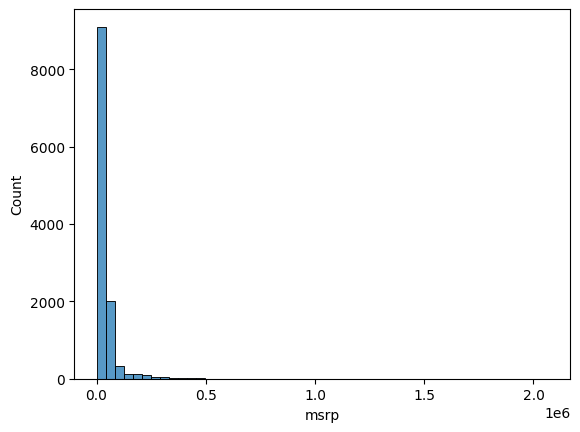

In [16]:
sns.histplot(df.msrp, bins = 50)

In [17]:
# This type of graph is know as longtail graph. There must be few cars that are priced at a very high value therefore we see this graph.
# This type of graph confuses our model.

In [18]:
# We can see that most of the cars are priced under 1 million dollars, so lets zoom-in.

<Axes: xlabel='msrp', ylabel='Count'>

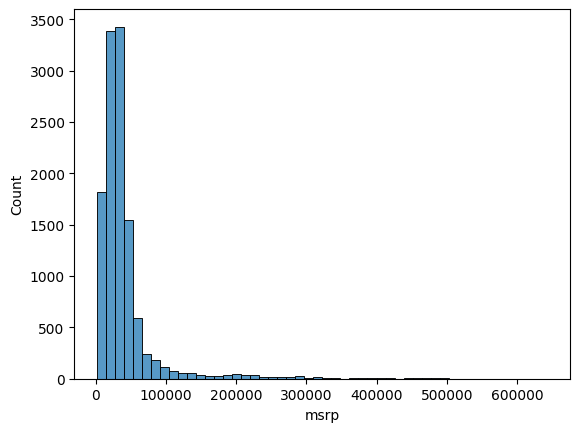

In [19]:
sns.histplot(df.msrp[df.msrp < 1000000], bins = 50)

In [20]:
# Since we have such big values in our data, if our model makes some error, it will be disasterous.
# Therefore, we need to reduce these numbers.

In [21]:
# To reduce these big numbers, we need to convert them into their natural log values.

In [22]:
np.log1p(df.msrp)

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

In [23]:
price_logs = np.log1p(df.msrp)

In [24]:
# Now let's see the MSRP for all cars again.

<Axes: xlabel='msrp', ylabel='Count'>

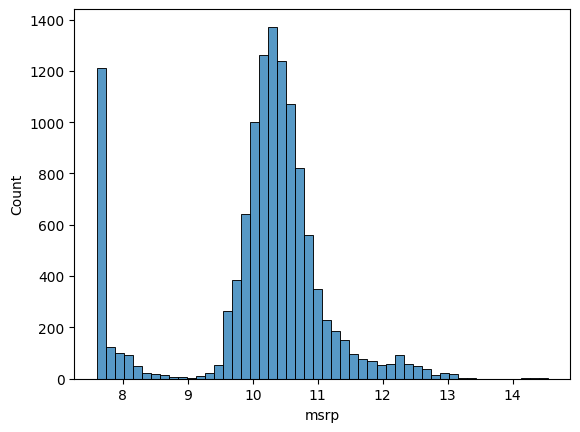

In [25]:
sns.histplot(price_logs, bins = 50)

In [26]:
# We can see that it has a bell curve shape. This type of graph is call Normal Distribution graph.
# This type of graph is really good for our model.

# Missing Values

In [27]:
# We can see that there are some missing values in our data.

In [28]:
df.isnull()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11910,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11911,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11912,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [29]:
# This wasn't helpful...

In [30]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# Validation Framework

In [31]:
n = len(df)

In [32]:
# Before we train our model, we need to split the data into three parts.
# We split the data into three parts [60:20:20] = [train:validation:test]

In [33]:
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = int(n - n_test - n_val)

In [34]:
n_train, n_val, n_test

(7150, 2382, 2382)

In [35]:
# Now that we have the counts for each data set, lets shuffle the dataset and break it.

In [36]:
idx = np.arange(n)

In [37]:
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [38]:
np.random.seed(2)
np.random.shuffle(idx)

In [39]:
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [40]:
df = df.iloc[idx]

In [41]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
11798,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
6637,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
2575,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [42]:
df_train = df[:n_train]
df_val = df[n_train: n_train + n_val]
df_test = df[n_train + n_val:]

In [43]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [44]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [45]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)
# We use log1p because itt adds 1 to the value and then finds natural log of the number.
# We do this because natural log of 0 is undefined.

In [46]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [47]:
# We will delete the msrp values from the datasets so that we don't accidently train with it.

In [48]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [49]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

# Baseline model for car price prediction model.

In [50]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    # Adding 1 to the begginging of feature matrix.
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    # return bias term and weights
    return w_full[0], w_full[1:]

In [51]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [52]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
# For now we are taking these features.

In [53]:
df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [54]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [55]:
X_train = df_train[base].fillna(0).values

In [56]:
# We already have y_train
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [57]:
train_linear_regression(X_train, y_train)

(np.float64(7.927257388069986),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [58]:
w0, w = train_linear_regression(X_train, y_train)

In [59]:
w0 + X_train.dot(w)

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

In [60]:
y_pred = w0 + X_train.dot(w)

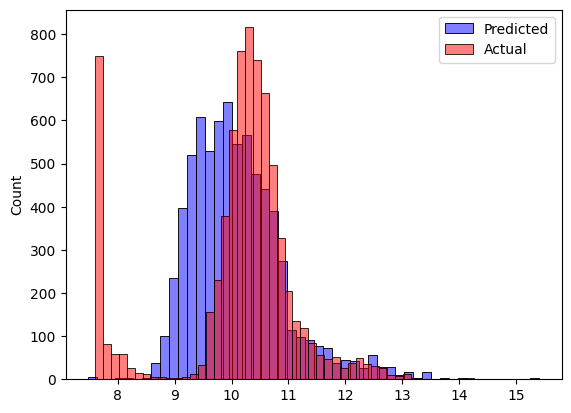

In [61]:
sns.histplot(y_pred, color = 'blue', alpha = 0.5, bins = 50, label='Predicted')
sns.histplot(y_train, color = 'red', alpha = 0.5, bins = 50, label='Actual')

plt.legend()
plt.show()

# RMSE

In [62]:
def rmse(y_pred, y):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)
    

In [63]:
rmse(y_pred, y_train)

np.float64(0.7554192603920132)

In [64]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

# Perform RMSE with Validation Data.

We can see how the weights we got from training data perform with validation data set.

In [65]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.761653099130156)

# Simple Feature Engineering

In [66]:
df.year.max()

np.int64(2017)

In [67]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [68]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.5172055461058299)

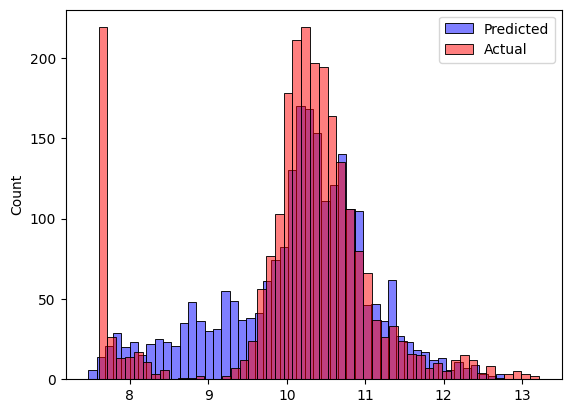

In [69]:
sns.histplot(y_pred, color = 'blue', alpha = 0.5, bins = 50, label='Predicted')
sns.histplot(y_val, color = 'red', alpha = 0.5, bins = 50, label='Actual')

plt.legend()
plt.show()

# Categorical Variables

### Now we have categorical data in our dataset which we want to use to train our model.

### We can do that by converting categorical feature columns to binary columns.
### For example, here in our dataset, we have number of doors in a car. It looks like a numerical feature but it is categorical feature.

### We have cars that have 2, 3 and 4 doors.
### So, we separate them into three columns.

### Suppose a car has 2 doors, we can break it down like this --> | 1 | 0 | 0 |.

### Similary, 3 doors as --> | 0 | 1 | 0 |. and 

### 4 doors --> | 0 | 0 | 1 |.


In [70]:
df_train[df_train.number_of_doors == 2]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
6,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520
7,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916
9,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657
10,rolls-royce,phantom_drophead_coupe,2015,premium_unleaded_(required),453.0,12.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,performance",large,convertible,19,11,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7130,gmc,sierra_1500_classic,2007,regular_unleaded,285.0,8.0,automatic,four_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,18,14,549
7134,dodge,ram_50_pickup,1991,regular_unleaded,116.0,4.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,22,17,1851
7136,toyota,camry_solara,2007,regular_unleaded,155.0,4.0,automatic,front_wheel_drive,2.0,NaN,midsize,coupe,31,22,2031
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916


In [71]:
(df_train.number_of_doors == 2).astype('int')

0       1
1       0
2       0
3       0
4       0
       ..
7145    1
7146    1
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

Let's rewrite our prepare_X function

In [72]:
def prepare_X(df):
    
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']

    for doors in [2, 3, 4]:
        df[f'num_doors_{doors}'] = (df_train.number_of_doors == doors).astype('int')
        features.append(f'num_doors_{doors}')
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [73]:
prepare_X(df_train)

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   1.],
       [563.,  12.,  21., ...,   0.,   0.,   1.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(7150, 9))

## Let's see it's effect of this feature on our model.

In [74]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.5186588617185612)

### We can see it has negligible effect, lets try with some more categorical variables

In [75]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [76]:
categorical_variables = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']

In [77]:
categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

In [78]:
categories.items()

dict_items([('make', ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']), ('engine_fuel_type', ['regular_unleaded', 'premium_unleaded_(required)', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)', 'diesel']), ('transmission_type', ['automatic', 'manual', 'automated_manual', 'direct_drive', 'unknown']), ('driven_wheels', ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']), ('market_category', ['crossover', 'flex_fuel', 'luxury', 'luxury,performance', 'hatchback']), ('vehicle_size', ['compact', 'midsize', 'large']), ('vehicle_style', ['sedan', '4dr_suv', 'coupe', 'convertible', '4dr_hatchback'])])

In [79]:
def prepare_X(df):
    
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']

    for doors in [2, 3, 4]:
        df[f'num_doors_{doors}'] = (df_train.number_of_doors == doors).astype('int')
        features.append(f'num_doors_{doors}')

    for name, values in categories.items():
        for value in values:
            df[f'{name}_{value}'] = (df[name] == value ).astype('int')
            features.append(f'{name}_{value}')


    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [80]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(39.08087777605988)

### We can see that this number is huge, it is basically really bad. But why did this happen?

# Regularization

### 1. The Problem: Exploding Weights & CollinearityPrior to this lesson, adding multiple categorical one-hot encoded features (or duplicate/collinear columns) caused the linear regression weights to explode to astronomical numbers (e.g., $10^{14}$–$10^{17}$). As a result:The training and validation Root Mean Squared Error (RMSE) skyrocketed.The Gram matrix $X^T X$ became singular or near-singular (linearly dependent columns), making matrix inversion $(X^T X)^{-1}$ impossible or numerically unstable.

### 2. The Regularization Solution (Ridge / L2 Regularization):
### To keep the weights under control, regularization modifies the normal equation by adding a small penalty $r$ along the diagonal of the feature correlation matrix:$$\mathbf{w} = \left(X^T X + r \cdot I\right)^{-1} X^T y$$Where:$X^T X$ is the dot product of feature matrices.$I$ is the identity matrix (np.eye(X.shape[1])).$r$ is the regularization parameter (a hyperparameter tuning the strength of regularization).

### 3. Key Takeaways from the VideoGuarantees Invertibility: 
### Adding $r \cdot I$ ensures the matrix $X^T X + r \cdot I$ always has full rank and can be cleanly inverted even with duplicate or highly correlated features.Controls Model Complexity: It constrains the size of coefficients ($w$), preventing the model from overfitting to noise in the training set. Hyperparameter Tuning: In the subsequent step, Alexey tests different values of $r$ (e.g., 0.001, 0.01, 0.1, 1, 10) on the validation set to find the optimal balance between bias and variance.

In [81]:
def train_linear_regression_reg(X, y, r = 0.01):
    ones = np.ones(X.shape[0])
    # Adding 1 to the begginging of feature matrix.
    X = np.column_stack([ones, X])

    
    XTX = X.T.dot(X)
    # We perform regularization on XTX to make the gram matrix inversion stable.
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    # return bias term and weights
    return w_full[0], w_full[1:]

In [82]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.4708490233625762)

### Now we see some improvement!!

# Tuning the model

### Now, we have to choose the best regularization value for best result from our model

In [83]:
for r in [0.0, 0.000001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    rmse_result = rmse(y_pred, y_val)

    print(f'r={r}, rmse_result={rmse_result}')

r=0.0, rmse_result=0.4708490233625762
r=1e-06, rmse_result=0.4708490233625762
r=0.0001, rmse_result=0.4708490233625762
r=0.001, rmse_result=0.4708490233625762
r=0.1, rmse_result=0.4708490233625762
r=1, rmse_result=0.4708490233625762
r=10, rmse_result=0.4708490233625762


In [84]:
r = 0.001
w0, w = train_linear_regression_reg(X_train, y_train, r= r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_pred, y_val)

np.float64(0.47085562204640496)

# Using the Model

### Remember that we have broken down our dataset into three parts, training, validation and test. Until now we used training data to get the weights and use to find RMSE from validation data. But now we will train our model on training and validation data and get weights from them and then use it on test data and find RMSE from it.

In [85]:
df_full_train = pd.concat([df_train, df_val])

In [86]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870
2378,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238
2379,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624
2380,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436


In [87]:
df_full_train = df_full_train.reset_index(drop= True)

In [88]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436


In [89]:
X_full_train = prepare_X(df_full_train)

In [90]:
y_full_train = np.concatenate([y_train, y_val])

In [91]:
y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(9532,))

In [92]:
r = 0.001
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r= r)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

rmse(y_pred, y_test)

np.float64(0.45718619941265)

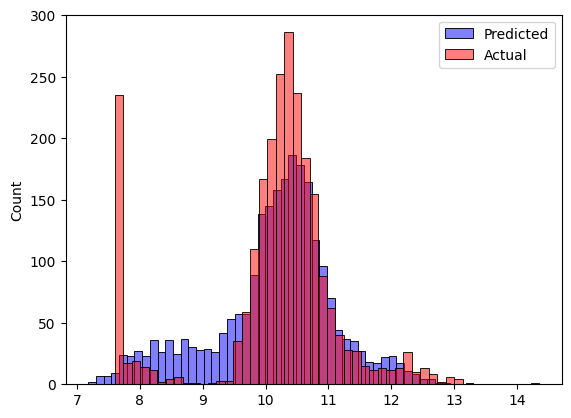

In [93]:
sns.histplot(y_pred, color = 'blue', alpha = 0.5, bins = 50, label='Predicted')
sns.histplot(y_test, color = 'red', alpha = 0.5, bins = 50, label='Actual')

plt.legend()
plt.show()

### Let's try our model on a car.

In [112]:
car = df_test.iloc[20].to_dict()

In [113]:
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [114]:
df_small = pd.DataFrame([car])

In [115]:
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [116]:
X_small = prepare_X(df_small)

In [117]:
X_small

array([[2.660e+02, 6.000e+00, 2.500e+01, 1.800e+01, 2.031e+03, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]])

In [118]:
y_pred = w0 + X_small.dot(w)
y_pred

array([10.36759833])

In [119]:
np.expm1(y_pred)

array([31810.98339563])

In [120]:
np.expm1(y_test[20])

np.float64(35000.00000000001)